In [ ]:
#| default_exp auto_transformation

## Automatic Transformations

peshbeen supports user-specified rolling window features — such as rolling means and standard deviations — which can be particularly useful for ML regressors as they capture recent dynamics in the series. Beyond feature engineering, peshbeen can automatically apply a Box-Cox transformation to the target variable when the data exhibits heteroscedasticity, stabilising variance before model fitting and improving forecast reliability.

In [ ]:
#| hide
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = "#FBFAF4"
plt.rcParams['axes.facecolor'] = "#FBFAF4"

# dont show warnings
import warnings
warnings.filterwarnings("ignore")

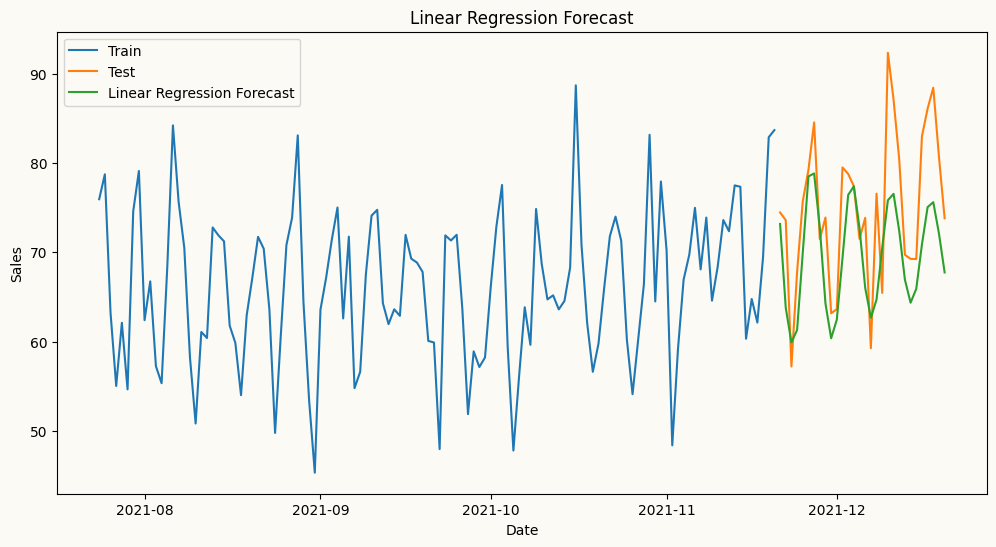

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from peshbeen.transformations import rolling_mean, rolling_quantile, rolling_std, expanding_mean
from peshbeen.models import ml_forecaster
from sklearn.linear_model import LinearRegression
date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
# create a non-stationary arbitrary flower sales data with an upward trend, weekly seasonality, and yearly seasonality
np.random.seed(42)
data = 30 + 0.07 * np.arange(720) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 5, 720)

sales_data = pd.DataFrame(data, index=date_range, columns=['sales'])
train = sales_data.iloc[:-30]
test = sales_data.iloc[-30:]
transformations = [rolling_std(window_size=30, shift=1), rolling_mean(window_size=30, shift=7),
                   rolling_quantile(window_size=30, shift=1, quantile=0.25),
                   rolling_quantile(window_size=30, shift=1, quantile=0.75), expanding_mean(shift=1)]
linear_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, box_cox=0.5,
              lag_transform=transformations)
linear_model.fit(train)
# linear_model.data_prep(train)
forecasts = linear_model.forecast(H=30)

# plot the forecast and the actual values
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, forecasts, label='Linear Regression Forecast')
plt.title('Linear Regression Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

For series with strong seasonal patterns, peshbeen can automatically generate Fourier terms as a DataFrame indexed to match the original series — making them ready to merge as exogenous variables in a single line. Calendar features such as month or day of week can be added directly to the same DataFrame, and peshbeen will automatically encode them as categorical variables. This covers a wide range of calendar effects, from weekend sales spikes to holiday demand shifts.

In [ ]:
from peshbeen.transformations import fourier_terms
# create fourier terms for yearly seasonality with period 365 and number of terms 2 to be used as exogenous variables in the model
sales_exog = sales_data.copy() # create a copy of the original data to store the fourier terms
# create day of week
sales_exog['day_of_week'] = sales_exog.index.dayofweek
cat_vars = ['day_of_week']
fourier_trms = fourier_terms(start_end_index=(sales_data.index[0], sales_data.index[-1]), period=365, num_terms=2)
sales_exog = sales_exog.merge(fourier_trms, left_index=True, right_index=True) # merge the fourier terms with the original data to be used as exogenous variables in the model
sales_exog.head()

,sales,day_of_week,sin_1_365,sin_2_365,cos_1_365,cos_2_365
2020-01-01,40.474019,2,0.000000,0.000000,1.000000,1.000000
2020-01-02,39.472174,3,0.017213,0.034422,0.999852,0.999407
2020-01-03,38.233477,4,0.034422,0.068802,0.999407,0.997630
2020-01-04,34.174336,5,0.051620,0.103102,0.998667,0.994671
2020-01-05,20.219602,6,0.068802,0.137279,0.997630,0.990532


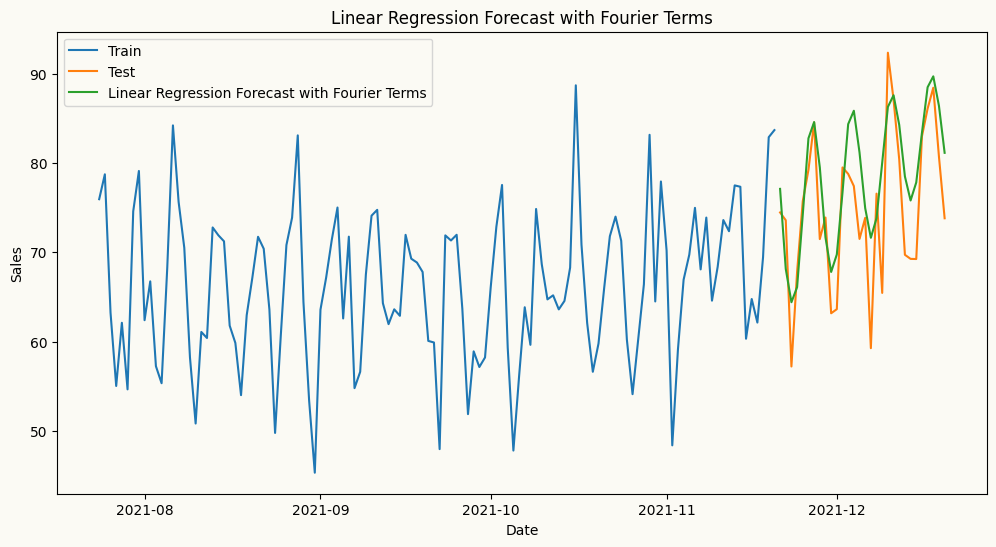

In [ ]:
# split the data into train and test
train_exog = sales_exog.iloc[:-30]
test_exog = sales_exog.iloc[-30:].drop(columns=['sales']) # drop the target column from the exogenous variables for the test set
# ml forecast using Linear Regression with fourier terms as exogenous variables
lr_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, box_cox=0.5, lag_transform=transformations)
lr_model.fit(train_exog)
lr_forecast = lr_model.forecast(H=30, exog=test_exog)
# plot the forecast and the actual values
plt.figure(figsize=(12, 6))
plt.plot(train.index[-120:], train['sales'][-120:], label='Train')
plt.plot(test.index, test['sales'], label='Test')
plt.plot(test.index, lr_forecast, label='Linear Regression Forecast with Fourier Terms')
plt.title('Linear Regression Forecast with Fourier Terms')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()